# Inspect RSA single tuning progression

This notebook loads the saved output of a single RSA tuning run and plots:

- fitted parameter development over epochs/steps,
- loss development over epochs/steps,

in one side-by-side figure.

It assumes your tuning script saved at least:

```text
single_tune_results/
  loss_values.npy
  all_params.npy
```

or, if you used the later saving version:

```text
single_tune_results/
  loss_values.npy
  params_history.npy
```


In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except ImportError:
    torch = None

try:
    import pandas as pd
except ImportError:
    pd = None

# ------------------------------------------------------------
# Change this if your outputs are saved somewhere else
# ------------------------------------------------------------
RUN_NM = 1
RESULTS_DIR = Path(f"single_tune_results_{RUN_NM}")

# True target values used in the run
THETA_TRUE = np.array([0.68, 0.98], dtype=float)

# Expected parameter order returned by RSA_tune in the locked setup
# params_final / all_params order:
#   [a1, a2, a3, b1, b2, b3]
PARAM_NAMES = ["a1", "a2", "a3", "b1", "b2", "b3"]

# Representative locked parameters
A_REP_COL = 0  # a1
B_REP_COL = 3  # b1

print("Results directory:", RESULTS_DIR.resolve())


Results directory: /pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/single_tune_results_1


In [15]:
def as_numeric_array(x):
    """
    Convert an object loaded from npy into a numeric numpy array.

    Handles:
      - numpy arrays
      - object arrays containing tensors/arrays
      - torch tensors
      - lists/tuples
    """
    if torch is not None and torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(float)

    if isinstance(x, np.ndarray):
        if x.dtype != object:
            return x.astype(float)

        # 0D object array
        if x.ndim == 0:
            return as_numeric_array(x.item())

        # Object array of rows/tensors
        rows = []
        for item in x:
            rows.append(as_numeric_array(item).reshape(-1))
        return np.stack(rows, axis=0).astype(float)

    if isinstance(x, (list, tuple)):
        rows = []
        for item in x:
            rows.append(as_numeric_array(item).reshape(-1))
        return np.stack(rows, axis=0).astype(float)

    return np.asarray(x, dtype=float)


def load_tuning_outputs(results_dir):
    """
    Load loss progression and parameter progression.

    Preferred parameter file:
      params_history.npy

    Fallback:
      all_params.npy

    Returns
    -------
    loss_values : np.ndarray
        Shape roughly (n_steps,)

    params_history : np.ndarray
        Shape roughly (n_steps, n_params)
    """
    results_dir = Path(results_dir)

    loss_path = results_dir / "loss_values.npy"
    params_history_path = results_dir / "params_history.npy"
    all_params_path = results_dir / "all_params.npy"

    if not loss_path.exists():
        raise FileNotFoundError(f"Could not find {loss_path}")

    loss_values = np.load(loss_path, allow_pickle=True)
    loss_values = as_numeric_array(loss_values).reshape(-1)

    if params_history_path.exists():
        raw_params = np.load(params_history_path, allow_pickle=True)
        params_history = as_numeric_array(raw_params)

    elif all_params_path.exists():
        raw_params = np.load(all_params_path, allow_pickle=True)
        params_history = as_numeric_array(raw_params)

    else:
        raise FileNotFoundError(
            f"Could not find either {params_history_path} or {all_params_path}"
        )

    if params_history.ndim == 1:
        params_history = params_history.reshape(-1, 1)

    return loss_values, params_history


loss_values, params_history = load_tuning_outputs(RESULTS_DIR)

print("loss_values shape:", loss_values.shape)
print("params_history shape:", params_history.shape)
print("first loss:", loss_values[0] if len(loss_values) else None)
print("last loss:", loss_values[-1] if len(loss_values) else None)
print("first params:", params_history[0])
print("last params:", params_history[-1])


loss_values shape: (75,)
params_history shape: (76, 6)
first loss: 0.21106763184070587
last loss: 0.015393172390758991
first params: [0.72000998 0.72000998 0.72000998 0.88001001 0.88001001 0.88001001]
last params: [0.66190898 0.66190898 0.66190898 0.95994598 0.95994598 0.95994598]


In [16]:
# ------------------------------------------------------------
# Optional table for quick inspection
# ------------------------------------------------------------
n_steps = max(len(loss_values), len(params_history))
step = np.arange(n_steps)

# Make a table only if pandas is available
if pd is not None:
    data = {"step": step}

    loss_padded = np.full(n_steps, np.nan)
    loss_padded[:len(loss_values)] = loss_values
    data["loss"] = loss_padded

    n_param_cols = params_history.shape[1]
    names = PARAM_NAMES[:n_param_cols]
    if len(names) < n_param_cols:
        names = names + [f"param_{i}" for i in range(len(names), n_param_cols)]

    for j, name in enumerate(names):
        col = np.full(n_steps, np.nan)
        col[:len(params_history)] = params_history[:, j]
        data[name] = col

    if params_history.shape[1] > B_REP_COL:
        data["a_rep"] = data[PARAM_NAMES[A_REP_COL]]
        data["b_rep"] = data[PARAM_NAMES[B_REP_COL]]

    df = pd.DataFrame(data)
    display(df.head())
    display(df.tail())
else:
    print("pandas not available; skipping table display.")


,step,loss,a1,a2,a3,b1,b2,b3,a_rep,b_rep
0,0,0.211068,0.720010,0.720010,0.720010,0.880010,0.880010,0.880010,0.720010,0.880010
1,1,0.083984,0.620010,0.620010,0.620010,0.980010,0.980010,0.980010,0.620010,0.980010
2,2,0.079119,0.625744,0.625744,0.625744,0.983291,0.983291,0.983291,0.625744,0.983291
3,3,0.028762,0.666283,0.666283,0.666283,0.950856,0.950856,0.950856,0.666283,0.950856
4,4,0.046822,0.676145,0.676145,0.676145,0.947360,0.947360,0.947360,0.676145,0.947360


,step,loss,a1,a2,a3,b1,b2,b3,a_rep,b_rep
71,71,0.017255,0.663450,0.663450,0.663450,0.960338,0.960338,0.960338,0.663450,0.960338
72,72,0.015340,0.661567,0.661567,0.661567,0.961710,0.961710,0.961710,0.661567,0.961710
73,73,0.016808,0.656323,0.656323,0.656323,0.966529,0.966529,0.966529,0.656323,0.966529
74,74,0.015393,0.657982,0.657982,0.657982,0.964368,0.964368,0.964368,0.657982,0.964368
75,75,NaN,0.661909,0.661909,0.661909,0.959946,0.959946,0.959946,0.661909,0.959946


Saved figure to: /pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/single_tune_results_1/parameter_and_loss_progression.png


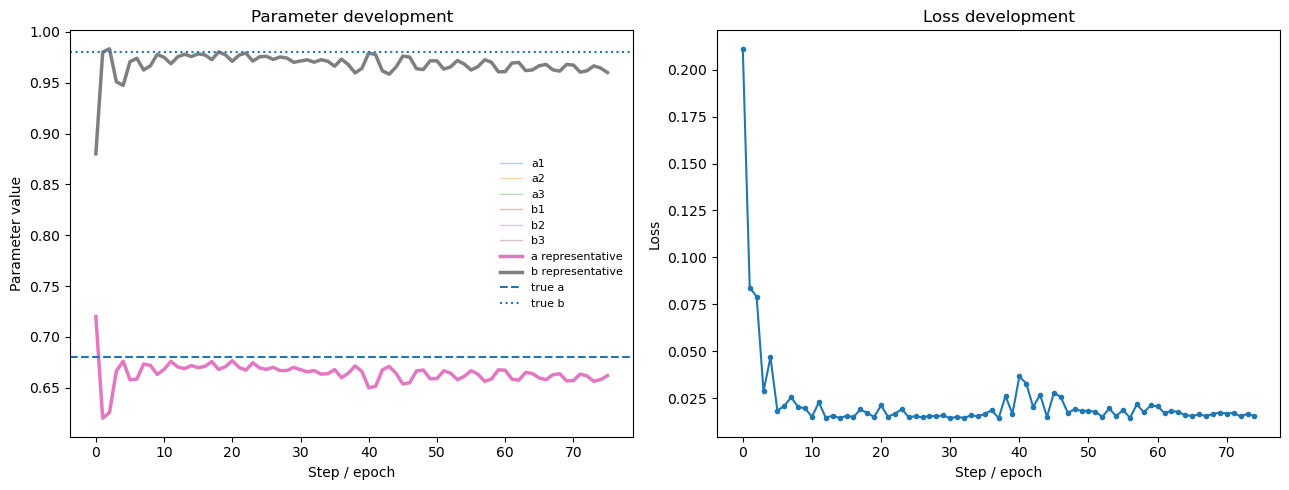

In [17]:
def plot_parameter_and_loss_progression(
    loss_values,
    params_history,
    theta_true=np.array([0.68, 0.98]),
    param_names=None,
    a_rep_col=0,
    b_rep_col=3,
    save_path=None,
):
    """
    Create one figure with two panels:

    left:
        parameter development over tuning steps/epochs

    right:
        loss development over tuning steps/epochs
    """
    loss_values = np.asarray(loss_values, dtype=float).reshape(-1)
    params_history = np.asarray(params_history, dtype=float)

    if params_history.ndim == 1:
        params_history = params_history.reshape(-1, 1)

    n_param_steps = params_history.shape[0]
    n_loss_steps = loss_values.shape[0]

    x_params = np.arange(n_param_steps)
    x_loss = np.arange(n_loss_steps)

    if param_names is None:
        param_names = [f"param_{j}" for j in range(params_history.shape[1])]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ------------------------------------------------------------
    # Left panel: parameter evolution
    # ------------------------------------------------------------
    ax = axes[0]

    # Plot all raw parameters lightly
    for j in range(params_history.shape[1]):
        name = param_names[j] if j < len(param_names) else f"param_{j}"
        ax.plot(x_params, params_history[:, j], alpha=0.35, linewidth=1.0, label=name)

    # Emphasize representative locked a and b
    if params_history.shape[1] > a_rep_col:
        ax.plot(
            x_params,
            params_history[:, a_rep_col],
            linewidth=2.5,
            label="a representative",
        )

    if params_history.shape[1] > b_rep_col:
        ax.plot(
            x_params,
            params_history[:, b_rep_col],
            linewidth=2.5,
            label="b representative",
        )

    ax.axhline(theta_true[0], linestyle="--", linewidth=1.5, label="true a")
    ax.axhline(theta_true[1], linestyle=":", linewidth=1.5, label="true b")

    ax.set_xlabel("Step / epoch")
    ax.set_ylabel("Parameter value")
    ax.set_title("Parameter development")
    ax.legend(frameon=False, fontsize=8)

    # ------------------------------------------------------------
    # Right panel: loss evolution
    # ------------------------------------------------------------
    ax = axes[1]

    ax.plot(x_loss, loss_values, marker="o", markersize=3, linewidth=1.5)
    ax.set_xlabel("Step / epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss development")

    # Useful when loss changes by orders of magnitude.
    # Uncomment if needed:
    # ax.set_yscale("log")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path.resolve())

    plt.show()


plot_parameter_and_loss_progression(
    loss_values,
    params_history,
    theta_true=THETA_TRUE,
    param_names=PARAM_NAMES,
    a_rep_col=A_REP_COL,
    b_rep_col=B_REP_COL,
    save_path=RESULTS_DIR / "parameter_and_loss_progression.png",
)


## How to read the figure

The left panel shows the parameter values stored in `all_params` or `params_history` at each optimization step.

For the locked 2D setup, the important representative parameters are usually:

```text
a = a1 = column 0
b = b1 = column 3
```

The horizontal reference lines show the target values:

```text
a_true = 0.68
b_true = 0.98
```

The right panel shows the loss value recorded at each step.

If the loss is noisy, check whether the overall trend decreases. If the loss jumps or plateaus, that may indicate learning-rate issues, a weak observable, or a problematic loss definition.


In [ ]:
# ------------------------------------------------------------
# Optional: check whether the locked parameters really stay locked
# ------------------------------------------------------------
if params_history.shape[1] >= 6:
    a_block = params_history[:, [0, 1, 2]]
    b_block = params_history[:, [3, 4, 5]]

    a_lock_spread = np.max(a_block, axis=1) - np.min(a_block, axis=1)
    b_lock_spread = np.max(b_block, axis=1) - np.min(b_block, axis=1)

    print("max spread among a1,a2,a3:", np.nanmax(a_lock_spread))
    print("max spread among b1,b2,b3:", np.nanmax(b_lock_spread))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(len(a_lock_spread)), a_lock_spread, label="spread a1,a2,a3")
    ax.plot(np.arange(len(b_lock_spread)), b_lock_spread, label="spread b1,b2,b3")
    ax.set_xlabel("Step / epoch")
    ax.set_ylabel("max - min")
    ax.set_title("Locked-parameter consistency check")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "locked_parameter_consistency.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough parameter columns to check locked a/b groups.")
